**Feature selection preprocessing**


Feature selection is a crucial preprocessing step in machine learning. It involves choosing the most relevant features from a dataset to improve model performance and reduce overfitting. While the original statement suggests that fewer features are always better, this isn't necessarily true. The goal is to find the optimal set of features that best represent the underlying patterns in the data.

**Feature Selection vs. Dimensionality Reduction**

It's important to distinguish between feature selection and dimensionality reduction techniques like PCA. Feature selection chooses a subset of original features, while dimensionality reduction creates new features that are combinations of the original ones.



In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder

# Load sample dataset
data = pd.DataFrame({
    'feature1': ['A', 'B', 'A', 'C', 'B', 'C'],
    'feature2': [1, 2, 1, 3, 2, 3],
    'target': [0, 1, 0, 1, 1, 0]
})

print(data.head())

  feature1  feature2  target
0        A         1       0
1        B         2       1
2        A         1       0
3        C         3       1
4        B         2       1


**Understanding Chi-Square (χ²) Test**

The Chi-Square test is a statistical method used to determine the independence between two categorical variables. In feature selection, it helps identify the features that have a significant relationship with the target variable. The test calculates a statistic that measures the difference between observed and expected frequencies.

In [ ]:
X = data[['feature1', 'feature2']]
y = data['target']

# Encode categorical variables
le = LabelEncoder()
X['feature1'] = le.fit_transform(X['feature1'])

# Perform Chi-Square test
selector = SelectKBest(score_func=chi2, k=2)
X_new = selector.fit_transform(X, y)

# Get feature scores
scores = selector.scores_
print("Feature scores:", scores)

Feature scores: [0.66666667 0.33333333]


/tmp/ipython-input-1131668968.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['feature1'] = le.fit_transform(X['feature1'])


**Interpreting Chi-Square Results**

The Chi-Square test produces a score for each feature. Higher scores indicate a stronger relationship between the feature and the target variable. We can use these scores to rank features and select the most relevant ones for our model.

In [ ]:
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
})

# Sort features by score in descending order
feature_scores = feature_scores.sort_values('Score', ascending=False)
print(feature_scores)

# Select top k features
k = 1  # Change this value to select more or fewer features
selected_features = feature_scores.head(k)['Feature'].tolist()
print("Selected features:", selected_features)

    Feature     Score
0  feature1  0.666667
1  feature2  0.333333
Selected features: ['feature1']


**Applying Feature Selection to the Dataset**

Once we've identified the most relevant features, we can create a new dataset containing only these features. This reduced dataset can then be used for training our machine learning model.

In [ ]:
X_selected = X[selected_features]
print("Original dataset shape:", X.shape)
print("Selected dataset shape:", X_selected.shape)

# Combine selected features with target variable
final_dataset = pd.concat([X_selected, y], axis=1)
print("\nFinal dataset:")
print(final_dataset.head())

Original dataset shape: (6, 2)
Selected dataset shape: (6, 1)

Final dataset:
   feature1  target
0         0       0
1         1       1
2         0       0
3         2       1
4         1       1


***Limitations of Chi-Square Test**

While the Chi-Square test is useful for categorical data, it has limitations. It assumes independence between observations and requires a sufficient sample size. For continuous features or more complex relationships, other feature selection methods might be more appropriate.

In [ ]:
data['continuous_feature'] = [0.1, 0.5, 0.2, 0.8, 0.3, 0.7]

X_cont = data[['continuous_feature']]

# Proper handling of continuous features
from sklearn.feature_selection import f_regression

f_scores, _ = f_regression(X_cont, y)
print("F-regression score for continuous feature:", f_scores)

F-regression score for continuous feature: [0.72]


++++++++++++++++++++++++++++++++

**Real-Life Example #1: Text Classification**

Let's consider a text classification problem where we want to categorize customer reviews as positive or negative. We'll use the Chi-Square test to select the most relevant words for our classification task.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample customer reviews
reviews = [
    "Great product, highly recommended!",
    "Terrible experience, avoid at all costs.",
    "Average product, nothing special.",
    "Excellent service and quality.",
    "Disappointing performance, would not buy again."
]
labels = [1, 0, 0, 1, 0]  # 1 for positive, 0 for negative

# Convert text to numerical features to be suitable for ML
# CountVectorizer() — create the text encoder: This initializes a Bag-of-Words (BoW) model.
# What it means:(1) Text is treated as a bag of word counts, (2) Order is ignored, (3) Only frequency matters
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(reviews)  # fit(reviews) — learn the vocabulary
print(X.toarray())



[[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0]
 [0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0]
 [1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1]]


In [ ]:
### print the number of unique vocabs
print("Number of vocabularies:", len(vectorizer.vocabulary_))

Number of vocabularies: 23


In [ ]:
# Perform Chi-Square test
selector = SelectKBest(score_func=chi2, k=5)
X_new = selector.fit_transform(X, labels)

# Get selected feature names
feature_names = vectorizer.get_feature_names_out()
selected_features = feature_names[selector.get_support()]

print("Selected words:", selected_features)

Selected words: ['great' 'highly' 'quality' 'recommended' 'service']


**Real-Life Example #2: Image Classification**

In image classification tasks, we often deal with high-dimensional data. Feature selection can help reduce the number of pixels or extracted features we use for classification. Here's a simplified example using random pixel values:

In [ ]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

# Generate random image data (100 images, 1000 pixels each)
X = np.random.rand(100, 1000)
y = np.random.randint(0, 2, 100)  # Binary classification

# Calculate mutual information between each pixel and the target
mi_scores = mutual_info_classif(X, y)

# Select top 100 pixels
top_pixels = np.argsort(mi_scores)[-100:]

# Create a new dataset with selected pixels
X_selected = X[:, top_pixels]

print("Original image shape:", X.shape)
print("Selected image shape:", X_selected.shape)

Original image shape: (100, 1000)
Selected image shape: (100, 100)


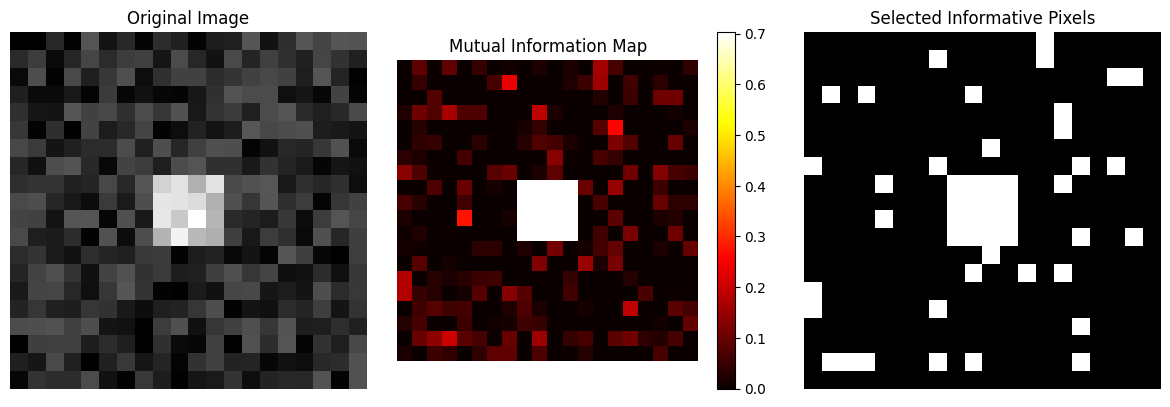

Original image shape: (50, 400)
Selected image shape: (50, 50)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# -------------------------------
# 1. Generate synthetic image data
# -------------------------------
np.random.seed(42)

n_samples = 50
img_height, img_width = 20, 20
n_pixels = img_height * img_width

# Create random images
X = np.random.rand(n_samples, n_pixels)

# Binary labels
y = np.array([0]*25 + [1]*25)

# Inject class-dependent signal (bright center square for class 1)
for i in range(25, 50):
    img = X[i].reshape(img_height, img_width)
    img[8:12, 8:12] += 2.0   # informative region
    X[i] = img.flatten()

# ----------------------------------------
# 2. Mutual Information feature selection
# ----------------------------------------
mi_scores = mutual_info_classif(X, y)

# Select top 50 informative pixels
top_pixels = np.argsort(mi_scores)[-50:]

# Reduced dataset
X_selected = X[:, top_pixels]

# -------------------------------
# 3. Visualization
# -------------------------------
# Pick one sample image
sample_idx = 40
original_image = X[sample_idx].reshape(img_height, img_width)

# Mutual Information heatmap
# 🔥 Bright (yellow/white) → high MI, 🌑 Dark → low MI
mi_map = mi_scores.reshape(img_height, img_width)

# Binary mask of selected pixels
mask = np.zeros(n_pixels)
mask[top_pixels] = 1
mask_image = mask.reshape(img_height, img_width)

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(original_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Mutual Information Map")
plt.imshow(mi_map, cmap='hot')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Selected Informative Pixels")
plt.imshow(mask_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# -------------------------------
# 4. Shape check
# -------------------------------
print("Original image shape:", X.shape)
print("Selected image shape:", X_selected.shape)


**Wrapper Methods for Feature Selection**

While filter methods like Chi-Square are computationally efficient, wrapper methods can sometimes yield better results by considering the specific model being used.

In [ ]:
### Recursive Feature Elimination (RFE)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Generate sample data
X = np.random.rand(100, 20)
y = np.random.randint(0, 2, 100)

# Create a logistic regression model
model = LogisticRegression()

# Perform RFE
rfe = RFE(estimator=model, n_features_to_select=5)
X_rfe = rfe.fit_transform(X, y)

# Get selected feature indices
selected_features = np.where(rfe.support_)[0]

print("Selected features:", selected_features)
print("Feature ranking:", rfe.ranking_)

Selected features: [ 3  4  6  7 12]
Feature ranking: [ 8  6  2  1  1 13  1  1 12 11 16  3  1 10  7 15  9  5  4 14]


**Embedded Methods: L1 Regularization**

Embedded methods perform feature selection as part of the model training process. L1 regularization (Lasso) is a popular technique that can lead to sparse models by driving some feature coefficients to zero.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# Generate sample data
X = np.random.rand(100, 20)
y = np.dot(X, np.random.rand(20)) + np.random.randn(100) * 0.1

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Lasso model
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)

# Print non-zero coefficients
non_zero = np.abs(lasso.coef_) > 1e-5
print("Selected features:", np.where(non_zero)[0])
print("Number of selected features:", np.sum(non_zero))

Selected features: [ 0  1  2  3  4  5  6  7 10 13 16 18 19]
Number of selected features: 13


**Cross-Validation in Feature Selection**

It's crucial to use cross-validation when performing feature selection to avoid overfitting. Here's an example using cross-validated recursive feature elimination (RFECV):

Optimal number of features: 11
Feature ranking: [ 1  4  1  3  1  1  7  9  2  1  1  1 10  1  8  6  5  1  1  1]


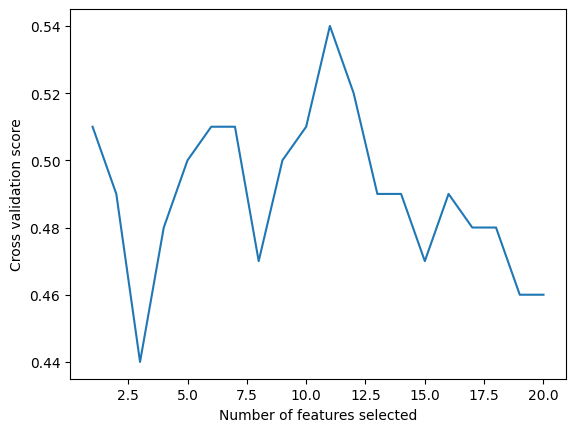

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV

# Generate sample data
X = np.random.rand(100, 20)
y = np.random.randint(0, 2, 100)

# Create a logistic regression model
model = LogisticRegression()

# Perform RFECV
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring='accuracy')
rfecv.fit(X, y)

print("Optimal number of features:", rfecv.n_features_)
print("Feature ranking:", rfecv.ranking_)

# Plot number of features VS. cross-validation scores
import matplotlib.pyplot as plt
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.show()

**Handling Multicollinearity**

Multicollinearity, where features are highly correlated with each other, can affect feature selection. Here's how to detect and handle it using Variance Inflation Factor (VIF):

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Generate sample data with multicollinearity
X = np.random.rand(100, 5)
X[:, 4] = X[:, 0] + X[:, 1] + np.random.randn(100) * 0.1

# Calculate VIF for each feature
vif = pd.DataFrame()
vif["Feature"] = range(X.shape[1])
vif["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print(vif)

# Remove features with high VIF
high_vif = vif[vif["VIF"] > 5]["Feature"].tolist()
X_reduced = np.delete(X, high_vif, axis=1)

print("Shape after removing high VIF features:", X_reduced.shape)

   Feature         VIF
0        0   48.493050
1        1   57.070486
2        2    3.311609
3        3    3.329105
4        4  181.359823
Shape after removing high VIF features: (100, 2)


**Ensemble Feature Selection**

Combining multiple feature selection methods can lead to more robust results. Here's an example that combines the results of different methods:

In [ ]:
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Generate sample data
X = np.random.rand(100, 20)
y = np.random.randint(0, 2, 100)

# Chi-Square
chi2_selector = SelectKBest(chi2, k=10)
chi2_support = chi2_selector.fit(X, y).get_support()

# Mutual Information
mi_selector = SelectKBest(mutual_info_classif, k=10)
mi_support = mi_selector.fit(X, y).get_support()

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)
rf_support = rf.feature_importances_ > np.mean(rf.feature_importances_)

# Combine results
combined_support = chi2_support & mi_support & rf_support
selected_features = np.where(combined_support)[0]

print("Selected features:", selected_features)
print("Number of selected features:", len(selected_features))

Selected features: [14 16 17]
Number of selected features: 3


**“Which feature selection method is faster on the same data?”**



1.   Chi-Square feature selection - SelectKBest(chi2, k=10)

* Statistical test
* Measures dependence between each feature and the class
* Assumes non-negative features
* Very fast (simple math)

Purpose: Select the 10 most relevant features based on Chi-Square scores.

2.   Mutual Information feature selection - SelectKBest(mutual_info_classif, k=10)

* Measures nonlinear dependency
* No distribution assumptions
* More powerful than Chi-Square
* Slower due to entropy estimation

Purpose: Select the 10 most informative features.

3. Random Forest - RandomForestClassifier(n_estimators=100)

* Ensemble of decision trees
* Learns feature importance implicitly
* Not a pure feature selector — it’s a full model
* Much more computationally expensive

Purpose: Learn which features matter while building a classifier.

In [ ]:
import time

# generate 1000 samples, 100 features per sample, Binary target (0 or 1)
X = np.random.rand(1000, 100)
y = np.random.randint(0, 2, 1000)

methods = [
    ("Chi-Square", SelectKBest(chi2, k=10)),
    ("Mutual Information", SelectKBest(mutual_info_classif, k=10)),
    ("Random Forest", RandomForestClassifier(n_estimators=100))
]

for name, method in methods:
    start_time = time.time()
    method.fit(X, y)
    elapsed_time = time.time() - start_time
    print(f"{name} took {elapsed_time:.4f} seconds")

Chi-Square took 0.0120 seconds
Mutual Information took 1.3477 seconds
Random Forest took 4.1063 seconds


___________________________________________
You can practice more :)